# Thesis Graphs Wrapper

Standalone notebook that builds every figure planned for the thesis (methodology + results sections). Re-runs the relevant slices of the feature-engineering pipeline locally so the notebook does **not** need to import the other notebooks. Nothing is exported to disk.

**Required local inputs** (all live under `./Data` and `./Feature selection log`):
1. `timeseries_<date>.csv` (wide-format Polymarket panel with `(variable, market)` MultiIndex columns - cached output of `PLS - Feature Engineering` Cell 5).
2. `polymarket_panel_filtered_<date>.csv` (final filtered panel, flat columns).
3. `Indicators Data bloomberg.xlsx` (raw Bloomberg workbook).
4. `Feature selection log/pls_n_components_latest.json`.

All palette / threshold knobs live in the **Config** cell below.


In [1]:
# %% -- CONFIG --------------------------------------------------------
from pathlib import Path

# Repo-relative paths (run from the repo root).
DATA_DIR        = Path('./Data')
RESULTS_DIR     = Path('./Results')
FEATURE_LOG_DIR = Path('./Feature selection log')

# Override the data-date used for file resolution; None -> latest available.
PANEL_DATE_OVERRIDE = None   # e.g. '2026-05-07'

# Bloomberg workbook + target sheet name (mirror Modelling Baseline / PLS FE).
BLOOMBERG_XLSX_PATH = DATA_DIR / 'Indicators Data bloomberg.xlsx'
TARGET_SHEET = 'GOLD USD SPOT PER OZ'

# Modelling cadence (must match the other notebooks).
BAR_MINUTES        = 5
RETURN_HORIZON_MIN = 60
HORIZON_STEPS      = max(1, RETURN_HORIZON_MIN // BAR_MINUTES)

# FE pipeline thresholds (must match PLS FE config).
MARKET_MIN_SPAN_RATIO        = 0.85
MARKET_EDGE_TOLERANCE_BARS   = 12
MISSINGNESS_FILTER_THRESHOLD = 0.15   # fraction (15%)
VARIANCE_FILTER_THRESHOLD    = 0.001
FSTAT_TOP_K_MARKETS          = 30

# Manual gold-irrelevant markets (copied verbatim from PLS FE).
NON_RELEVANT_MARKETS = [
    "Trump's face on US gold coin by July 4?",
    'Will Dan Goldman be the Democratic nominee for NY-10?',
    'Will Goldman Sachs fail by June 30, 2026?',
    'Will Jared Golden be the Democratic nominee for ME-02?',
    'Will Jared Golden be the Democratic nominee for Senate in Maine?',
    'Will Oro launch a token by December 31, 2026?',
    'Will Oro launch a token by June 30, 2026?',
    'Will Oro launch a token by September 30, 2026?',
    'Will Trump sell 1-100 Gold Cards in 2026?',
    'Will Trump sell 101-1k Gold Cards in 2026?',
    'Will Trump sell 10k-25k Gold Cards in 2026?',
    'Will Trump sell 1k-2.5k Gold Cards in 2026?',
    'Will Trump sell 2.5k-5k Gold Cards in 2026?',
    'Will Trump sell 25k-100k Gold Cards in 2026?',
    'Will Trump sell 5k-10k Gold Cards in 2026?',
    'Will Trump sell over 100k Gold Cards in 2026?',
]

# Columns dropped before pivoting (matches PLS FE COLS_TO_DROP, retained so the
# timeseries CSV is interpreted identically here).
COLS_TO_DROP_VARS = {
    'id', 'conditionId', 'slug', 'questionID', 'clobTokenIds', 'icon', 'image',
    'description', 'resolutionSource', 'events', 'umaResolutionStatuses',
    'submitted_by', 'marketMakerAddress', 'seriesColor', 'liquidityAmm',
    'oneYearPriceChange', 'volume1moAmm', 'volume1wkAmm', 'volume1yrAmm',
    'volume24hrAmm', 'volumeAmm', 'umaResolutionStatus', 'negRiskMarketID',
    'negRiskRequestID', 'resolvedBy',
}

# ---------------- Palette ------------------------------------------------
# 'Sunsetdark' is the active reference palette. SUNSETDARK_HEX mirrors plotly's
# sequential.Sunsetdark so matplotlib / seaborn share the exact same hex stops.
PLOTLY_SEQ_NAME = 'Sunsetdark'
SUNSETDARK_HEX = [
    '#fcde9c', '#faa476', '#f0746e', '#e34f6f',
    '#dc3977', '#b9257a', '#7c1d6f',
]
PALETTE_HEX_OVERRIDE = None   # paste any list of hex codes to override

# Human-readable labels for Bloomberg sheets (used in Graph 5).
SHEET_LABELS = {
    'CRUDE OIL (WTI) FUTURES PRICE':   'WTI Crude Oil',
    'CRUDE OIL (BRENT) FUTURES PRICE': 'Brent Crude Oil',
    'S&P 500 Index':                   'S&P 500',
    'USD Index':                       'USD Index',
    'VIX Index':                       'VIX',
    'USGG10YR Index':                  'US 10Y Treasury',
    'EURUSD':                          'EUR/USD',
    'GC1 Comdty':                      'Gold Futures (GC1)',
    'GLD US Equity':                   'GLD ETF',
}

print('Config loaded.')


Config loaded.


In [2]:
# %% -- DEPENDENCIES --------------------------------------------------
import re
import json
import ast
import warnings
import sys
import importlib.util
from hashlib import md5


def _ensure(pip_name: str, import_name: str | None = None) -> None:
    """Install *pip_name* via pip if *import_name* (or *pip_name*) is not importable."""
    check = import_name or pip_name
    if importlib.util.find_spec(check) is None:
        import subprocess
        print(f'  Installing {pip_name} ...')
        subprocess.check_call(
            [sys.executable, '-m', 'pip', 'install', pip_name, '-q']
        )


_ensure('numpy')
_ensure('pandas')
_ensure('matplotlib')
_ensure('seaborn')
_ensure('plotly')
_ensure('scipy')
_ensure('pyarrow')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from scipy import stats
import pyarrow.parquet as pq

warnings.filterwarnings('ignore')
np.random.seed(42)

pio.templates.default = 'plotly_white'
sns.set_style('whitegrid')

print('Dependencies loaded.')


Dependencies loaded.


In [3]:
# %% -- PALETTE HELPERS ----------------------------------------------
PALETTE_HEX = list(PALETTE_HEX_OVERRIDE) if PALETTE_HEX_OVERRIDE else list(SUNSETDARK_HEX)

# Continuous (sequential) colormap derived from the same hex stops.
SEQ_CMAP_MPL = LinearSegmentedColormap.from_list('thesis_seq', PALETTE_HEX, N=256)

# Diverging variant: mirror the palette around a neutral midpoint.
DIVERGING_CMAP_MPL = LinearSegmentedColormap.from_list(
    'thesis_div', [PALETTE_HEX[-1], '#f7f7f7', PALETTE_HEX[0]], N=256,
)

# Apply the palette to seaborn (used as the default qualitative palette).
sns.set_palette(PALETTE_HEX)


def palette_colors(n: int) -> list[str]:
    """Return n hex colors evenly spaced along the active palette."""
    if n <= 1:
        return [PALETTE_HEX[len(PALETTE_HEX) // 2]]
    if n <= len(PALETTE_HEX):
        idx = np.linspace(0, len(PALETTE_HEX) - 1, n).astype(int)
        return [PALETTE_HEX[i] for i in idx]
    return [mcolors.rgb2hex(SEQ_CMAP_MPL(i / (n - 1))) for i in range(n)]


print(f'Palette ready ({len(PALETTE_HEX)} hex stops).')


Palette ready (7 hex stops).


In [4]:
# %% -- FILE RESOLUTION -----------------------------------------------
_DATE_RX = re.compile(r'(\d{4}-\d{2}-\d{2})')


def find_latest_file(folder: Path, pattern: str):
    candidates = []
    for p in folder.glob(pattern):
        m = _DATE_RX.search(p.name)
        if m:
            candidates.append((m.group(1), p))
    if not candidates:
        return None, None
    candidates.sort(key=lambda x: x[0])
    return candidates[-1][1], candidates[-1][0]


_filt_path, _filt_date = find_latest_file(DATA_DIR, 'polymarket_panel_filtered_*.csv')
panel_date = PANEL_DATE_OVERRIDE or _filt_date
if panel_date is None:
    raise FileNotFoundError(
        f'No polymarket_panel_filtered_*.csv found in {DATA_DIR}. '
        'Run the PLS Feature Engineering notebook first.'
    )

panel_filtered_path = DATA_DIR / f'polymarket_panel_filtered_{panel_date}.csv'
timeseries_path     = DATA_DIR / f'timeseries_{panel_date}.csv'
fstat_path          = DATA_DIR / f'fstat_market_ranking_{panel_date}.csv'
pls_log_path        = FEATURE_LOG_DIR / 'pls_n_components_latest.json'

for label, path, required in [
    ('Bloomberg workbook',              BLOOMBERG_XLSX_PATH, True),
    ('Polymarket filtered panel',       panel_filtered_path, True),
    ('Polymarket wide timeseries CSV',  timeseries_path,     True),
    ('F-stat market ranking CSV',       fstat_path,          False),
    ('PLS n_components log',            pls_log_path,        True),
]:
    exists = path.exists()
    marker = 'OK ' if exists else ('MISSING' if required else 'opt  ')
    print(f'  [{marker}] {label:<35} {path}')
    if required and not exists:
        raise FileNotFoundError(f'{label} not found at {path}')

print(f'\nUsing data date: {panel_date}')


  [OK ] Bloomberg workbook                  Data\Indicators Data bloomberg.xlsx
  [OK ] Polymarket filtered panel           Data\polymarket_panel_filtered_2026-05-07.csv
  [OK ] Polymarket wide timeseries CSV      Data\timeseries_2026-05-07.csv
  [OK ] F-stat market ranking CSV           Data\fstat_market_ranking_2026-05-07.csv
  [OK ] PLS n_components log                Feature selection log\pls_n_components_latest.json

Using data date: 2026-05-07


## Stage 1 - Load wide-format Polymarket panel

Loads `timeseries_<date>.csv` (MultiIndex columns `(variable, market)`). This is the heaviest step (the CSV is several hundred MB). The loader mirrors `PLS - Feature Engineering Cell 7` so the in-memory frame matches that notebook.


In [5]:
# %% -- LOAD WIDE-FORMAT POLYMARKET PANEL ------------------------------
import csv
import pyarrow
import pyarrow.csv as pa_csv

print(f'Loading {timeseries_path.name} ...')
print(f'  File size: {timeseries_path.stat().st_size / (1024**2):.1f} MB')

# Step 1: read the two header rows manually. Asking the C engine to build
# a 2-level MultiIndex via header=[0, 1] on a ~1 GB file is the main
# OOM trigger - pandas pre-allocates a whole-file tokenisation buffer
# when it has to look ahead for the header structure.
with open(timeseries_path, 'r', encoding='utf-8', newline='') as _hf:
    _rdr = csv.reader(_hf)
    _hdr_var = next(_rdr)
    _hdr_mkt = next(_rdr)
_column_tuples = list(zip(_hdr_var[1:], _hdr_mkt[1:]))

# Step 2: load the data body with a low-memory parser. pyarrow.csv is used
# directly (bypassing the pandas engine='pyarrow' wrapper, which has a known
# bug mapping skiprows on large files). If pyarrow fails, fall back to a
# chunked C-engine read so the tokeniser never has to hold the whole file at once.
df_wide = None
_engine_used = None
try:
    _read_opts = pa_csv.ReadOptions(skip_rows=2, autogenerate_column_names=True)
    _pa_table = pa_csv.read_csv(timeseries_path, read_options=_read_opts)
    df_wide = _pa_table.to_pandas()
    df_wide = df_wide.set_index(df_wide.columns[0])
    _engine_used = 'pyarrow'
except Exception as _exc:
    print(
        f'  [info] pyarrow engine unavailable or failed '
        f'({type(_exc).__name__}: {_exc}); '
        'falling back to chunked C engine ...'
    )
    try:
        _chunks = []
        for _chunk in pd.read_csv(
            timeseries_path,
            skiprows=2,
            header=None,
            index_col=0,
            chunksize=1000,
            low_memory=True,
        ):
            _chunks.append(_chunk)
        df_wide = pd.concat(_chunks)
        del _chunks
        _engine_used = 'c-chunked'
    except Exception as _exc2:
        raise RuntimeError(
            f'Failed to load {timeseries_path.name} with both pyarrow and '
            f'chunked-C engines: {type(_exc2).__name__}: {_exc2}. '
            'Close other applications to free RAM, install pyarrow '
            "(`pip install pyarrow`), or run on a machine with more memory."
        ) from _exc2

# Step 3: re-attach datetime index + (variable, market) MultiIndex columns.
df_wide.index = pd.to_datetime(df_wide.index, errors='coerce')
df_wide = df_wide.loc[df_wide.index.notna()]
df_wide.columns = pd.MultiIndex.from_tuples(
    _column_tuples, names=['variable', 'market']
)

# Enforce COLS_TO_DROP on the cached CSV (mirrors PLS FE behaviour).
_stale_cols = [c for c in df_wide.columns if c[0] in COLS_TO_DROP_VARS]
if _stale_cols:
    df_wide = df_wide.drop(columns=_stale_cols)

INITIAL_VARS    = df_wide.columns.get_level_values(0).nunique()
INITIAL_MARKETS = df_wide.columns.get_level_values(1).nunique()
INITIAL_COLS    = df_wide.shape[1]

print(f'  Engine used      : {_engine_used}')
print(f'  Wide panel shape : {df_wide.shape}')
print(f'  Date range       : {df_wide.index.min()} -> {df_wide.index.max()}')
print(f'  Unique variables : {INITIAL_VARS}')
print(f'  Unique markets   : {INITIAL_MARKETS}')


Loading timeseries_2026-05-07.csv ...
  File size: 932.5 MB
  [info] pyarrow engine unavailable or failed (ArrowInvalid: Could not skip initial 2 rows from CSV file, either file is too short or header is larger than block size); falling back to chunked C engine ...
  Engine used      : c-chunked
  Wide panel shape : (10702, 19099)
  Date range       : 2026-03-30 15:15:52.586000 -> 2026-05-07 22:00:17.478000
  Unique variables : 76
  Unique markets   : 268


## Stage 2 - Load Bloomberg workbook + compute gold log-returns

`load_bloomberg` is copied from `Modelling Baseline` Cell 16. Once gold is loaded we compute (i) per-bar 5-min log-returns and (ii) the horizon-shifted target `y_t = log(P_{t+H}) - log(P_t)` exactly as the modelling notebooks define it.


In [6]:
# %% -- LOAD BLOOMBERG WORKBOOK + BUILD GOLD TARGETS ------------------
def load_bloomberg(xlsx_path: Path) -> dict[str, pd.DataFrame]:
    """Mirror of Modelling Baseline load_bloomberg().
    Sheets are normalised so the close column is always named 'close'.
    """
    xl = pd.ExcelFile(xlsx_path)
    out = {}
    for sheet in xl.sheet_names:
        df = pd.read_excel(xlsx_path, sheet_name=sheet, header=0)
        if df.empty or 'Date' not in df.columns:
            continue
        df = df.rename(columns={c: c.strip() for c in df.columns})
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
        df = df.dropna(subset=['Date']).set_index('Date').sort_index()
        for col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        if 'Close' in df.columns:
            df = df.rename(columns={'Close': 'close'})
        elif 'Last Price' in df.columns:
            df = df.rename(columns={'Last Price': 'close'})
        else:
            numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
            if not numeric_cols:
                continue
            df = df.rename(columns={numeric_cols[-1]: 'close'})
        out[sheet] = df
    return out


bb = load_bloomberg(BLOOMBERG_XLSX_PATH)
print(f'Bloomberg sheets : {list(bb.keys())}')

gold = bb[TARGET_SHEET][['close']].rename(columns={'close': 'gold_close'}).copy()
gold['logret_bar']     = np.log(gold['gold_close']).diff()
gold['logret_horizon'] = (
    np.log(gold['gold_close']) - np.log(gold['gold_close']).shift(HORIZON_STEPS)
)
gold['y'] = gold['logret_horizon'].shift(-HORIZON_STEPS)

print(
    f'Gold panel: rows={len(gold)}  '
    f'range={gold.index.min()} -> {gold.index.max()}'
)
print(
    f'y stats   : mean={gold["y"].mean():.3e}  std={gold["y"].std():.3e}  '
    f'horizon={RETURN_HORIZON_MIN} min'
)


Bloomberg sheets : ['GOLD USD SPOT PER OZ', 'CRUDE OIL (WTI) FUTURES PRICE', 'CRUDE OIL (BRENT) FUTURES PRICE', 'S&P 500 Index', 'USD Index', 'VIX Index', 'USGG10YR Index', 'EURUSD', 'GC1 Comdty', 'GLD US Equity']
Gold panel: rows=7459  range=2026-04-01 00:00:00 -> 2026-05-08 22:55:00
y stats   : mean=1.431e-05  std=3.206e-03  horizon=60 min


## Stage 3 - Re-run the FE pipeline (counts + missingness)

Replays the feature-engineering pipeline locally so we have the intermediate datasets the plots depend on. Logic copied from `PLS - Feature Engineering` (Cells 14, 16, 18, 19, 33, 42).

**Cell 8a** - span filter + numeric/JSON expansion.


In [7]:
# %% -- FE STEP A : SPAN FILTER + JSON/NUMERIC EXPANSION ---------------
_markets_initial = df_wide.columns.get_level_values(1).unique().tolist()

dataset_start = df_wide.index.min()
dataset_end   = df_wide.index.max()
dataset_span  = dataset_end - dataset_start

median_step = df_wide.index.to_series().diff().dropna().median()
if pd.isna(median_step) or median_step <= pd.Timedelta(0):
    median_step = pd.Timedelta(minutes=BAR_MINUTES)
edge_tolerance = MARKET_EDGE_TOLERANCE_BARS * median_step

full_length_markets = []
for market in _markets_initial:
    sub = df_wide.xs(market, axis=1, level=1)
    row_has_data = sub.notna().any(axis=1)
    if not row_has_data.any():
        continue
    first_obs = sub.index[row_has_data][0]
    last_obs  = sub.index[row_has_data][-1]
    market_span = last_obs - first_obs
    span_ratio  = market_span / dataset_span if dataset_span > pd.Timedelta(0) else 1.0
    start_gap   = first_obs - dataset_start
    end_gap     = dataset_end - last_obs
    keep_market = (
        (start_gap <= edge_tolerance and end_gap <= edge_tolerance)
        or span_ratio >= MARKET_MIN_SPAN_RATIO
    )
    if keep_market:
        full_length_markets.append(market)

cols_to_drop = [c for c in df_wide.columns if c[1] not in full_length_markets]
df_full_range = df_wide.drop(columns=cols_to_drop)
POSTSPAN_MARKETS = df_full_range.columns.get_level_values(1).nunique()
POSTSPAN_VARS    = df_full_range.columns.get_level_values(0).nunique()
POSTSPAN_COLS    = df_full_range.shape[1]
print(
    f'After span filter ({MARKET_MIN_SPAN_RATIO:.0%}): '
    f'{POSTSPAN_MARKETS} markets, {POSTSPAN_VARS} vars, {POSTSPAN_COLS} cols'
)

# ---- Numeric / JSON expansion (copied from PLS FE Cell 16) -----------
_multiindex_names = df_full_range.columns.names
_original_predictor_frame = df_full_range.copy()


def _parse_numeric_list(value):
    if not isinstance(value, str):
        return None
    value = value.strip()
    if not value:
        return None
    parsed = None
    try:
        parsed = json.loads(value)
    except (json.JSONDecodeError, ValueError):
        pass
    if parsed is None:
        try:
            parsed = ast.literal_eval(value)
        except (ValueError, SyntaxError):
            return None
    if isinstance(parsed, (list, tuple)):
        result = []
        for x in parsed:
            try:
                result.append(float(x))
            except (TypeError, ValueError):
                pass
        return result if result else None
    if isinstance(parsed, (int, float)) and not isinstance(parsed, bool):
        return [float(parsed)]
    return None


def _safe_feature_name(text):
    text = str(text).strip().lower()
    text = re.sub(r'[^0-9a-zA-Z]+', '_', text).strip('_')
    return text or 'value'


def _parse_label_list(value):
    if not isinstance(value, str):
        return None
    value = value.strip()
    if not value:
        return None
    try:
        parsed = json.loads(value)
    except json.JSONDecodeError:
        try:
            parsed = ast.literal_eval(value)
        except (ValueError, SyntaxError):
            return None
    if isinstance(parsed, list):
        return [str(x) for x in parsed]
    return None


def _expand_json_numeric_columns(sub, var_name):
    expanded_cols = {}
    label_sub = None
    if var_name == 'outcomePrices' and 'outcomes' in _original_predictor_frame.columns.get_level_values(0):
        try:
            label_sub = _original_predictor_frame['outcomes'].reindex(columns=sub.columns)
        except Exception:
            label_sub = None

    for market in sub.columns:
        series = sub[market]
        parsed_rows = {}
        label_series = None
        if label_sub is not None:
            if isinstance(label_sub, pd.Series):
                if market == label_sub.name:
                    label_series = label_sub
            elif market in label_sub.columns:
                label_series = label_sub[market]

        for idx, raw_value in series.dropna().items():
            try:
                parsed_values = _parse_numeric_list(raw_value)
            except Exception:
                continue
            if parsed_values is None:
                continue
            if not isinstance(parsed_values, (list, tuple)):
                continue
            if len(parsed_values) == 0:
                continue
            labels = None
            if label_series is not None and idx in label_series.index:
                labels = _parse_label_list(label_series.loc[idx])
            for pos, numeric_value in enumerate(parsed_values):
                numeric_value = pd.to_numeric(numeric_value, errors='coerce')
                if pd.isna(numeric_value):
                    continue
                if labels is not None and pos < len(labels):
                    suffix = _safe_feature_name(labels[pos])
                else:
                    suffix = f'json_{pos}'
                derived_var = f'{var_name}__{suffix}'
                parsed_rows.setdefault(derived_var, {})[idx] = float(numeric_value)
        for derived_var, row_map in parsed_rows.items():
            expanded_cols[(derived_var, market)] = pd.Series(
                row_map, index=sub.index, dtype='float64'
            )
    if not expanded_cols:
        return None
    expanded_df = pd.DataFrame(expanded_cols, index=sub.index)
    expanded_df.columns = pd.MultiIndex.from_tuples(
        expanded_df.columns, names=_multiindex_names
    )
    return expanded_df.sort_index(axis=1)


_predictor_vars = sorted([
    v for v in df_full_range.columns.get_level_values(0).unique()
    if v not in {'y', 'gold_close'}
])
_passthrough_cols = [
    col for col in df_full_range.columns if col[0] in {'y', 'gold_close'}
]
_transformed_blocks = []
_numerical_predictors = []
_non_numerical_predictors = []
_json_expanded_predictors = {}

for var in _predictor_vars:
    sub = df_full_range[var]
    if isinstance(sub, pd.Series):
        sub = sub.to_frame()
    coerced = sub.apply(pd.to_numeric, errors='coerce')
    has_numeric_signal = coerced.notna().any().any()
    if has_numeric_signal:
        coerced.columns = pd.MultiIndex.from_product(
            [[var], coerced.columns], names=_multiindex_names
        )
        _transformed_blocks.append(coerced)
        _numerical_predictors.append(var)
    else:
        expanded_json = _expand_json_numeric_columns(sub, var)
        if expanded_json is not None and expanded_json.notna().any().any():
            _transformed_blocks.append(expanded_json)
            derived = sorted(expanded_json.columns.get_level_values(0).unique())
            _numerical_predictors.extend(derived)
            _json_expanded_predictors[var] = derived
        else:
            _non_numerical_predictors.append(var)

_predictor_frame_numeric = (
    pd.concat(_transformed_blocks, axis=1).sort_index(axis=1)
    if _transformed_blocks else pd.DataFrame(index=df_full_range.index)
)
if _passthrough_cols:
    _passthrough_frame = df_full_range.loc[:, _passthrough_cols]
    df_full_range_numerical = pd.concat(
        [_passthrough_frame, _predictor_frame_numeric], axis=1
    ).sort_index(axis=1)
else:
    df_full_range_numerical = _predictor_frame_numeric.sort_index(axis=1).copy()

POSTNUMERIC_COLS    = df_full_range_numerical.shape[1]
POSTNUMERIC_VARS    = df_full_range_numerical.columns.get_level_values(0).nunique()
POSTNUMERIC_MARKETS = df_full_range_numerical.columns.get_level_values(1).nunique()
print(
    f'After numeric/JSON expansion: '
    f'{POSTNUMERIC_MARKETS} markets, {POSTNUMERIC_VARS} vars, {POSTNUMERIC_COLS} cols'
)
print(f'  JSON-expanded predictors: {_json_expanded_predictors}')


After span filter (85%): 59 markets, 75 vars, 4349 cols
After numeric/JSON expansion: 59 markets, 62 vars, 3654 cols
  JSON-expanded predictors: {'outcomePrices': ['outcomePrices__no', 'outcomePrices__yes']}


**Cell 8b** - missingness summary + variance filter + manual + F-stat filters.


In [8]:
# %% -- FE STEP B : MISSINGNESS / VARIANCE / MANUAL / F-STAT ----------
# ---- Missingness analysis (PLS FE Cell 18) ---------------------------
_pred_vars_miss = [
    v for v in df_full_range_numerical.columns.get_level_values(0).unique()
    if v not in {'y', 'gold_close'}
]
_miss_rows = []
for _var in _pred_vars_miss:
    _sub = df_full_range_numerical[_var]
    if isinstance(_sub, pd.Series):
        _sub = _sub.to_frame()
    _sub_num = _sub.apply(pd.to_numeric, errors='coerce')
    _overall_miss = float(_sub_num.isna().values.mean())
    _per_market = _sub_num.isna().mean()
    _miss_rows.append({
        'variable':              _var,
        'n_markets':             int(_sub_num.shape[1]),
        'overall_miss_pct':      round(_overall_miss * 100, 2),
        'worst_market_miss_pct': round(float(_per_market.max()) * 100, 2),
        'best_market_miss_pct':  round(float(_per_market.min()) * 100, 2),
        'flagged':               _overall_miss > MISSINGNESS_FILTER_THRESHOLD,
    })
missingness_summary = (
    pd.DataFrame(_miss_rows)
    .sort_values('overall_miss_pct', ascending=False)
    .reset_index(drop=True)
)
_dropped_miss_vars = missingness_summary.loc[
    missingness_summary['flagged'], 'variable'
].tolist()
_miss_cols = [
    col for col in df_full_range_numerical.columns
    if col[0] in set(_dropped_miss_vars)
]
df_postmiss = df_full_range_numerical.drop(columns=_miss_cols).ffill()
POSTMISS_COLS    = df_postmiss.shape[1]
POSTMISS_VARS    = df_postmiss.columns.get_level_values(0).nunique()
POSTMISS_MARKETS = df_postmiss.columns.get_level_values(1).nunique()
print(
    f'After missingness filter (>{MISSINGNESS_FILTER_THRESHOLD:.0%}): '
    f'{POSTMISS_MARKETS} markets, {POSTMISS_VARS} vars, {POSTMISS_COLS} cols  '
    f'(dropped {len(_dropped_miss_vars)} var{"s" if len(_dropped_miss_vars) != 1 else ""})'
)

# ---- Variance filter on min-max normalised pooled series (PLS FE Cell 30) ----
_pred_vars_var = [
    v for v in df_postmiss.columns.get_level_values(0).unique()
    if v not in {'y', 'gold_close'}
]
variances = []
for var in _pred_vars_var:
    sub = df_postmiss[var]
    if isinstance(sub, pd.Series):
        sub = sub.to_frame()
    numeric_sub = sub.apply(pd.to_numeric, errors='coerce')
    arr_raw = numeric_sub.to_numpy(dtype='float64')
    if np.isfinite(arr_raw).sum() < 2:
        variances.append({'variable': var, 'variance': 0.0})
        continue
    min_val = np.nanmin(arr_raw)
    max_val = np.nanmax(arr_raw)
    value_range = max_val - min_val
    if not np.isfinite(value_range) or value_range == 0:
        variances.append({'variable': var, 'variance': 0.0})
        continue
    arr_norm = (arr_raw - min_val) / value_range
    variances.append({'variable': var, 'variance': float(np.nanvar(arr_norm, ddof=1))})
var_df = pd.DataFrame(variances).sort_values('variance', ascending=False).reset_index(drop=True)
_low_var_vars = set(var_df.loc[var_df['variance'] < VARIANCE_FILTER_THRESHOLD, 'variable'].tolist())
_var_cols_to_drop = [c for c in df_postmiss.columns if c[0] in _low_var_vars]
df_postvar = df_postmiss.drop(columns=_var_cols_to_drop)
POSTVAR_COLS    = df_postvar.shape[1]
POSTVAR_VARS    = df_postvar.columns.get_level_values(0).nunique()
POSTVAR_MARKETS = df_postvar.columns.get_level_values(1).nunique()
print(
    f'After variance filter (>={VARIANCE_FILTER_THRESHOLD}): '
    f'{POSTVAR_MARKETS} markets, {POSTVAR_VARS} vars, {POSTVAR_COLS} cols  '
    f'(dropped {len(_low_var_vars)} var{"s" if len(_low_var_vars) != 1 else ""})'
)

# ---- Manual non-relevant market exclusion (PLS FE Cell 42) -----------
_manual_drop_cols = [c for c in df_postvar.columns if c[1] in set(NON_RELEVANT_MARKETS)]
df_postmanual = df_postvar.drop(columns=_manual_drop_cols)
POSTMANUAL_COLS    = df_postmanual.shape[1]
POSTMANUAL_VARS    = df_postmanual.columns.get_level_values(0).nunique()
POSTMANUAL_MARKETS = df_postmanual.columns.get_level_values(1).nunique()
print(
    f'After manual market exclusion: '
    f'{POSTMANUAL_MARKETS} markets, {POSTMANUAL_VARS} vars, {POSTMANUAL_COLS} cols'
)

# ---- F-statistic top-K market filter ---------------------------------
# Use the precomputed ranking CSV when available; otherwise fall back to
# the alphabetical first-K (only relevant for the funnel count).
if fstat_path.exists():
    fstat_df = pd.read_csv(fstat_path)
    _kept_markets = (
        fstat_df[fstat_df['market'].isin(df_postmanual.columns.get_level_values(1))]
        .sort_values('F', ascending=False)
        .head(FSTAT_TOP_K_MARKETS)['market'].tolist()
    )
else:
    print(f'  [warn] {fstat_path.name} not found - using first {FSTAT_TOP_K_MARKETS} markets')
    _kept_markets = list(df_postmanual.columns.get_level_values(1).unique())[:FSTAT_TOP_K_MARKETS]
df_postfstat = df_postmanual.loc[:, df_postmanual.columns.get_level_values(1).isin(_kept_markets)]
POSTFSTAT_COLS    = df_postfstat.shape[1]
POSTFSTAT_VARS    = df_postfstat.columns.get_level_values(0).nunique()
POSTFSTAT_MARKETS = df_postfstat.columns.get_level_values(1).nunique()
print(
    f'After F-stat top-{FSTAT_TOP_K_MARKETS}: '
    f'{POSTFSTAT_MARKETS} markets, {POSTFSTAT_VARS} vars, {POSTFSTAT_COLS} cols'
)

# ---- PLS reduction (load from artefact) ------------------------------
PLS_META = json.loads(pls_log_path.read_text(encoding='utf-8'))
PLS_N_COMPONENTS = int(PLS_META['n_components'])
print(f'PLS n_components selected: {PLS_N_COMPONENTS}')


After missingness filter (>15%): 59 markets, 50 vars, 2946 cols  (dropped 12 vars)
After variance filter (>=0.001): 59 markets, 22 vars, 1298 cols  (dropped 28 vars)
After manual market exclusion: 43 markets, 22 vars, 946 cols
After F-stat top-30: 30 markets, 22 vars, 660 cols
PLS n_components selected: 3


## Graph 1 - Polymarket variable-level missingness

Vertical bar chart of the per-variable missingness rate (averaged over markets x timestamps), sorted descending. The dashed line marks the 15% filter threshold from §3.3.2; bars above it are the ones dropped.


In [9]:
# %% -- GRAPH 1 : MISSINGNESS BAR CHART (Plotly) ----------------------
_m_sorted = missingness_summary.sort_values('overall_miss_pct', ascending=False)

fig_g1 = px.bar(
    _m_sorted,
    x='variable',
    y='overall_miss_pct',
    color='overall_miss_pct',
    color_continuous_scale=PLOTLY_SEQ_NAME,
    title='Polymarket variable-level missingness',
    labels={'overall_miss_pct': 'Missingness (%)', 'variable': 'Variable'},
)
fig_g1.add_hline(
    y=MISSINGNESS_FILTER_THRESHOLD * 100,
    line_dash='dash',
    line_color='black',
    annotation_text=f'{MISSINGNESS_FILTER_THRESHOLD * 100:.0f}% filter threshold',
    annotation_position='top right',
)
fig_g1.update_layout(
    xaxis_tickangle=-45,
    height=560,
    coloraxis_colorbar=dict(title='Missingness (%)'),
)
fig_g1.show()


## Graph 2 - Distribution of the target Y (gold log-returns)

Histogram + KDE of the realised forward log-return at the configured horizon (`RETURN_HORIZON_MIN`). The dashed line marks the empirical mean; the dotted vertical at zero is a visual anchor for symmetry.


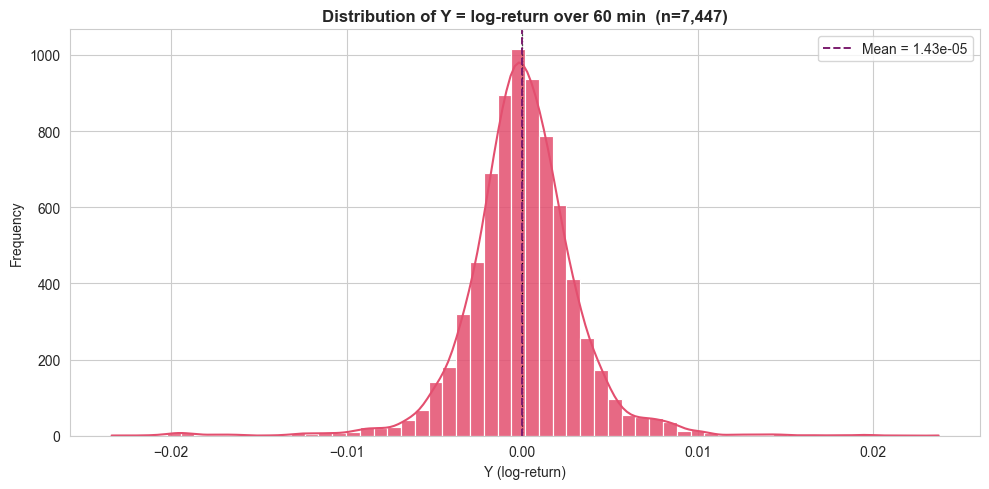

In [10]:
# %% -- GRAPH 2 : Y DISTRIBUTION (Seaborn / Matplotlib) ----------------
y_series = gold['y'].dropna()

fig_g2, ax_g2 = plt.subplots(figsize=(10, 5))
sns.histplot(
    y_series,
    bins=60,
    kde=True,
    color=PALETTE_HEX[3],
    edgecolor='white',
    alpha=0.85,
    ax=ax_g2,
)
ax_g2.axvline(0, color='black', linestyle=':', linewidth=0.9)
ax_g2.axvline(
    y_series.mean(),
    color=PALETTE_HEX[-1],
    linestyle='--',
    linewidth=1.4,
    label=f'Mean = {y_series.mean():.2e}',
)
ax_g2.set_title(
    f'Distribution of Y = log-return over {RETURN_HORIZON_MIN} min  '
    f'(n={len(y_series):,})',
    fontweight='bold',
)
ax_g2.set_xlabel('Y (log-return)')
ax_g2.set_ylabel('Frequency')
ax_g2.legend()
fig_g2.tight_layout()
plt.show()


## Graph 3 - PLS walk-forward CV: RMSE vs n_components

Reproduces the selection plot stored in `Feature selection log/pls_n_components_latest.json` (PLS FE Cell 51). The selected `n_components` (lowest mean CV RMSE) is highlighted with a star.


In [11]:
# %% -- GRAPH 3 : PLS RMSE vs n_components (Plotly) ------------------
_pls_payload = json.loads(pls_log_path.read_text(encoding='utf-8'))
_grid  = sorted(int(k) for k in _pls_payload['rmse_by_n_components'])
_rmse  = [_pls_payload['rmse_by_n_components'][str(n)] for n in _grid]
_se    = [_pls_payload['rmse_se_by_n_components'][str(n)] for n in _grid]
_best_n  = int(_pls_payload['selected_by_min_rmse'])
_best_v  = _pls_payload['rmse_by_n_components'][str(_best_n)]

fig_g3 = go.Figure()
fig_g3.add_trace(go.Scatter(
    x=_grid, y=_rmse,
    mode='lines+markers',
    name='Mean CV RMSE',
    line=dict(color=PALETTE_HEX[-1], width=2),
    marker=dict(color=PALETTE_HEX[-1], size=8),
    error_y=dict(type='data', array=_se, color=PALETTE_HEX[2], thickness=1.2),
))
fig_g3.add_trace(go.Scatter(
    x=[_best_n], y=[_best_v],
    mode='markers',
    name=f'Selected n={_best_n}',
    marker=dict(color=PALETTE_HEX[0], size=18, symbol='star',
                line=dict(color='black', width=1.4)),
))
fig_g3.update_layout(
    title=(
        f'PLS walk-forward CV - RMSE vs n_components  '
        f'(selected n={_best_n}, horizon={RETURN_HORIZON_MIN} min)'
    ),
    xaxis_title='n_components',
    yaxis_title='Mean CV RMSE (+/- 1 SE)',
    height=500,
)
fig_g3.show()


## Graph 4 - Gold spot vs 5-min log-returns (two-panel, mean + trend overlay)

Top panel: raw `gold_close` (visibly non-stationary - has a trend). Bottom panel: per-bar log-returns (stationary - oscillates around zero with vol clustering). Each panel overlays the empirical mean (dashed) and an OLS trend in time (solid). Used to justify the log-return transformation in §3.1.2 of the thesis.


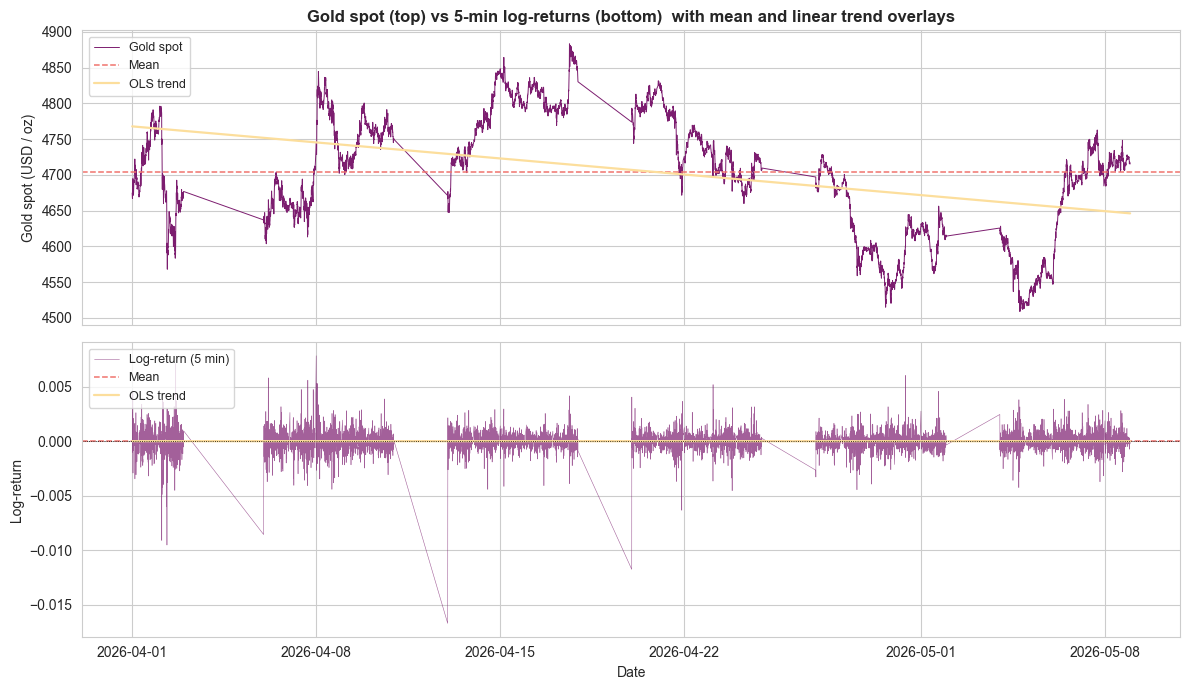

In [26]:
# %% -- GRAPH 4 : GOLD PRICE + LOG-RETURNS (Matplotlib 2-panel) -------
_gc = gold['gold_close'].dropna()
_gr = gold['logret_bar'].dropna()

_t_close = (_gc.index - _gc.index[0]).total_seconds() / 3600.0
_slope_c, _intercept_c, *_ = stats.linregress(_t_close, _gc.values)
_t_ret = (_gr.index - _gr.index[0]).total_seconds() / 3600.0
_slope_r, _intercept_r, *_ = stats.linregress(_t_ret, _gr.values)

fig_g4, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Top panel - gold spot
axes[0].plot(_gc.index, _gc.values, color=PALETTE_HEX[-1],
             linewidth=0.7, label='Gold spot')
axes[0].axhline(_gc.mean(), color=PALETTE_HEX[2], linestyle='--',
                linewidth=1.1, label=f'Mean')
axes[0].plot(_gc.index, _intercept_c + _slope_c * _t_close,
             color=PALETTE_HEX[0], linewidth=1.6, linestyle='-',
             label=f'OLS trend')
axes[0].set_ylabel('Gold spot (USD / oz)')
axes[0].set_title(
    'Gold spot (top) vs 5-min log-returns (bottom)  '
    'with mean and linear trend overlays',
    fontweight='bold',
)
axes[0].legend(loc='upper left', fontsize=9)

# Bottom panel - log-returns
axes[1].plot(_gr.index, _gr.values, color=PALETTE_HEX[-1],
             linewidth=0.4, alpha=0.7, label='Log-return (5 min)')
axes[1].axhline(_gr.mean(), color=PALETTE_HEX[2], linestyle='--',
                linewidth=1.1, label=f'Mean')
axes[1].plot(_gr.index, _intercept_r + _slope_r * _t_ret,
             color=PALETTE_HEX[0], linewidth=1.6, linestyle='-',
             label=f'OLS trend')
axes[1].axhline(0, color='black', linestyle=':', linewidth=0.6)
axes[1].set_ylabel('Log-return')
axes[1].set_xlabel('Date')
axes[1].legend(loc='upper left', fontsize=9)

fig_g4.tight_layout()
plt.show()


## Graph 5 - Bloomberg indicators vs gold log-returns (faceted scatter)

One scatter facet per Bloomberg indicator. X = forward-filled indicator value on the 5-min gold clock; Y = forward log-return of gold (target Y). Each facet shows an OLS regression line so trend and mean of each relationship can be inspected at a glance.


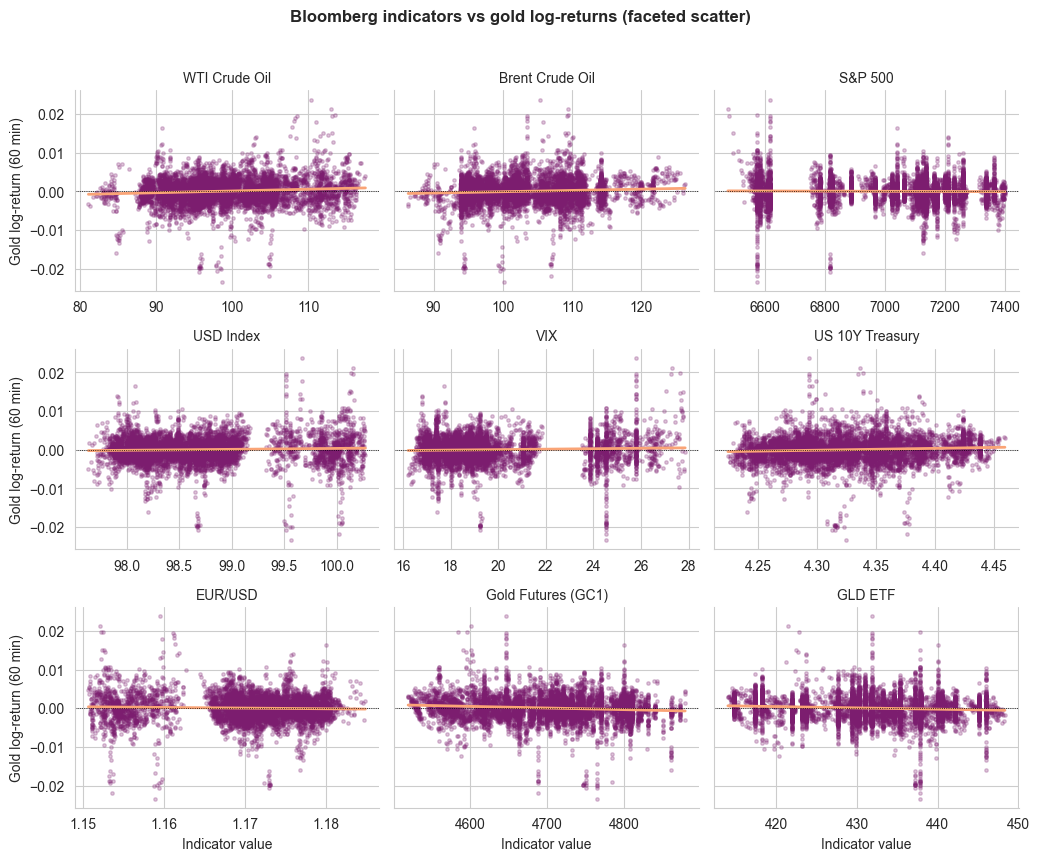

In [13]:
# %% -- GRAPH 5 : BLOOMBERG vs GOLD-LOGRET (Seaborn FacetGrid) ---------
_bb_indicators = [s for s in bb if s != TARGET_SHEET]

_records = []
for sheet in _bb_indicators:
    s = bb[sheet]['close'].sort_index()
    s = s[~s.index.duplicated(keep='last')]
    s_5m = s.reindex(gold.index, method='ffill')
    label = SHEET_LABELS.get(sheet, sheet)
    df_tmp = pd.DataFrame({
        'indicator_value': s_5m.values,
        'gold_logret_y':   gold['y'].values,
        'sheet':           label,
    }, index=gold.index).dropna()
    _records.append(df_tmp)
all_long = pd.concat(_records, ignore_index=True)

g_g5 = sns.FacetGrid(
    all_long, col='sheet', col_wrap=3,
    sharex=False, sharey=True, height=2.8, aspect=1.25,
)
g_g5.map_dataframe(
    sns.regplot,
    x='indicator_value', y='gold_logret_y',
    scatter_kws=dict(s=6, alpha=0.25, color=PALETTE_HEX[-1]),
    line_kws=dict(color=PALETTE_HEX[1], linewidth=2),
    ci=None,
)
for ax in g_g5.axes.flat:
    ax.axhline(0, color='black', linestyle=':', linewidth=0.6)
g_g5.set_titles(col_template='{col_name}')
g_g5.set_axis_labels('Indicator value', f'Gold log-return ({RETURN_HORIZON_MIN} min)')
g_g5.fig.suptitle(
    'Bloomberg indicators vs gold log-returns (faceted scatter)',
    y=1.02, fontweight='bold',
)
g_g5.fig.tight_layout()
plt.show()


## Graph 6 - Polymarket FE pipeline funnel

Total column count `(variable x market)` at each FE filter, ending with the PLS-reduced latent components. Counts are computed live from the FE replay above, so toggling any threshold in the Config cell will update the funnel.


In [14]:
# %% -- GRAPH 6 : FE PIPELINE FUNNEL (Plotly) -------------------------
_funnel_steps = pd.DataFrame([
    {'step': '1. Raw wide panel',
     'n_cols': INITIAL_COLS,
     'desc':  f'{INITIAL_VARS} vars x {INITIAL_MARKETS} markets'},
    {'step': f'2. Span filter (>= {MARKET_MIN_SPAN_RATIO:.0%})',
     'n_cols': POSTSPAN_COLS,
     'desc':  f'{POSTSPAN_VARS} vars x {POSTSPAN_MARKETS} markets'},
    {'step': '3. Numeric / JSON expansion',
     'n_cols': POSTNUMERIC_COLS,
     'desc':  f'{POSTNUMERIC_VARS} vars x {POSTNUMERIC_MARKETS} markets'},
    {'step': f'4. Missingness filter (> {MISSINGNESS_FILTER_THRESHOLD:.0%})',
     'n_cols': POSTMISS_COLS,
     'desc':  f'{POSTMISS_VARS} vars x {POSTMISS_MARKETS} markets'},
    {'step': f'5. Variance filter (>= {VARIANCE_FILTER_THRESHOLD})',
     'n_cols': POSTVAR_COLS,
     'desc':  f'{POSTVAR_VARS} vars x {POSTVAR_MARKETS} markets'},
    {'step': '6. Manual market exclusion',
     'n_cols': POSTMANUAL_COLS,
     'desc':  f'{POSTMANUAL_VARS} vars x {POSTMANUAL_MARKETS} markets'},
    {'step': f'7. F-statistic top-{FSTAT_TOP_K_MARKETS} markets',
     'n_cols': POSTFSTAT_COLS,
     'desc':  f'{POSTFSTAT_VARS} vars x {POSTFSTAT_MARKETS} markets'},
    {'step': f'8. PLS reduction (n_components = {PLS_N_COMPONENTS})',
     'n_cols': PLS_N_COMPONENTS,
     'desc':  f'{PLS_N_COMPONENTS} latent components'},
])

fig_g6 = go.Figure(go.Funnel(
    y=_funnel_steps['step'],
    x=_funnel_steps['n_cols'],
    text=_funnel_steps['desc'],
    textposition='inside',
    textinfo='value+text',
    marker=dict(
        color=palette_colors(len(_funnel_steps)),
        line=dict(color='white', width=1),
    ),
    connector=dict(line=dict(color='lightgray', width=1)),
))
fig_g6.update_layout(
    title='Polymarket FE pipeline - column count at each filter step',
    height=620,
    margin=dict(l=240, r=60, t=80, b=60),
)
fig_g6.show()


## Graph 7 - Correlation heatmap of outcomePrices__yes vs other Polymarket vars

Per-market correlation between the `outcomePrices__yes` series and every other Polymarket variable (cell = within-market Pearson correlation). Rows = markets retained after the F-stat filter, columns = sibling variables. Uses the post-filter panel (`polymarket_panel_filtered_<date>.csv`) so column naming is `<var>__<market_slug>_<hash6>`.


In [15]:
# %% -- GRAPH 7 : COV HEATMAP outcomePrices__yes ----------------------
panel_filt = pd.read_csv(
    panel_filtered_path, parse_dates=['scraped_at'], index_col='scraped_at'
)


def _parse_flat_column(col: str):
    """Split '<var>__<slug>_<hash6>' -> (var, market_id). var may itself
    contain '__' (e.g. 'outcomePrices__yes')."""
    parts = col.split('__')
    if len(parts) < 2:
        return col, ''
    return '__'.join(parts[:-1]), parts[-1]


_col_map = {_parse_flat_column(c): c for c in panel_filt.columns}
_all_markets = sorted({m for (_, m) in _col_map.keys()})
_all_vars    = sorted({v for (v, _) in _col_map.keys() if v != 'outcomePrices__yes'})

_corr_matrix = pd.DataFrame(index=_all_markets, columns=_all_vars, dtype=float)
_min_overlap = 30
for market in _all_markets:
    yes_col = _col_map.get(('outcomePrices__yes', market))
    if yes_col is None:
        continue
    y_series = panel_filt[yes_col]
    for var in _all_vars:
        other_col = _col_map.get((var, market))
        if other_col is None:
            continue
        joined = pd.concat([y_series, panel_filt[other_col]], axis=1).dropna()
        if len(joined) < _min_overlap:
            continue
        c = joined.iloc[:, 0].corr(joined.iloc[:, 1])
        if pd.notna(c):
            _corr_matrix.loc[market, var] = float(c)

# Drop rows / cols that are entirely NaN to keep the heatmap readable.
_corr_matrix = _corr_matrix.dropna(how='all', axis=0).dropna(how='all', axis=1)

# Shorten market labels for the y-axis.
_short_idx = [m[:60] + ('...' if len(m) > 60 else '') for m in _corr_matrix.index]

fig_g7 = px.imshow(
    _corr_matrix.values,
    x=_corr_matrix.columns,
    y=_short_idx,
    color_continuous_scale=PLOTLY_SEQ_NAME,
    color_continuous_midpoint=0.0,
    aspect='auto',
    labels=dict(x='Polymarket variable', y='Market',
                color='Pearson correlation'),
    title='Per-market correlation: outcomePrices__yes vs other Polymarket variables',
)
fig_g7.update_layout(
    height=max(450, 22 * len(_corr_matrix)),
    xaxis_tickangle=-45,
    margin=dict(l=420, r=40, t=80, b=120),
)
fig_g7.show()


## Stage 4 - Load Results / Predictions / Models (resilient)

Discovers `summary_h<H>m_<date>.csv`, `*.predictions.csv`, and `*.pkl` model artefacts in `./Results/` and `./Models/`. Every graph in this section degrades gracefully when files are missing: a heatmap with three horizons out of four still plots, an absent prediction sidecar skips the figure with a warning, etc. Re-running an upstream notebook later (e.g. with the LSTM results) and re-executing the cells below is enough to refresh every plot.


In [16]:
# %% -- LOAD SUMMARIES / PREDICTIONS / MODELS ------------------------
MODELS_DIR = Path('./Models')

_summary_rx = re.compile(r'^summary_h(\d+)m_(\d{4}-\d{2}-\d{2})\.csv$')
_pred_rx = re.compile(
    r'^(?P<model>.+?)_(?P<window>fixed\d+|expanding)_(?P<dataset>[a-z0-9+_]+)'
    r'_h(?P<h>\d+)m_f(?P<f>\d+)_(?P<date>\d{4}-\d{2}-\d{2})$'
)


def load_summary_files() -> dict[int, pd.DataFrame]:
    """Return {horizon_min: DataFrame} for every summary CSV we find.
    Note: these CSVs are written by Modelling Baseline from the *current
    session*'s `all_results`, so they routinely miss models trained in
    earlier sessions. Treat them as a hint, not the source of truth.
    """
    out: dict[int, pd.DataFrame] = {}
    for path in sorted(RESULTS_DIR.glob('summary_h*m_*.csv')):
        m = _summary_rx.match(path.name)
        if not m:
            continue
        try:
            df = pd.read_csv(path)
        except Exception as exc:
            print(f'  [warn] {path.name}: {exc}')
            continue
        if df.empty:
            continue
        h = int(m.group(1))
        if h in out and out[h].attrs.get('date', '') > m.group(2):
            continue
        df.attrs['date'] = m.group(2)
        df.attrs['path'] = str(path)
        out[h] = df
    return out


def discover_prediction_files() -> dict[tuple, Path]:
    """Map (model_lower, window, dataset, horizon_min) -> latest predictions.csv."""
    out: dict[tuple, Path] = {}
    best_date: dict[tuple, str] = {}
    for path in sorted(RESULTS_DIR.glob('*.predictions.csv')):
        stem = path.name[:-len('.predictions.csv')]
        m = _pred_rx.match(stem)
        if not m:
            continue
        key = (m['model'].lower(), m['window'], m['dataset'], int(m['h']))
        if best_date.get(key, '') < m['date']:
            best_date[key] = m['date']
            out[key] = path
    return out


def discover_model_files() -> dict[tuple, Path]:
    """Map (model_lower, window, dataset, horizon_min) -> latest .pkl path."""
    out: dict[tuple, Path] = {}
    best_date: dict[tuple, str] = {}
    if not MODELS_DIR.exists():
        return out
    for path in sorted(MODELS_DIR.glob('*.pkl')):
        m = _pred_rx.match(path.stem)
        if not m:
            continue
        key = (m['model'].lower(), m['window'], m['dataset'], int(m['h']))
        if best_date.get(key, '') < m['date']:
            best_date[key] = m['date']
            out[key] = path
    return out


def build_summary_from_run_metadata() -> pd.DataFrame:
    """Source-of-truth summary: parse every per-run JSON sidecar in Results/.

    Modelling Baseline writes one `{STEM}.json` per `(model, window, dataset,
    horizon)` combination at training time, so these sidecars persist across
    sessions while the aggregated `summary_h<H>m_<date>.csv` files do not.
    For each `(dataset, model, window, horizon)` key we keep the JSON with
    the most recent `data_date` (and, ties broken by `run_utc`).
    """
    by_key: dict[tuple, dict] = {}
    by_key_date: dict[tuple, tuple[str, str]] = {}
    for path in sorted(RESULTS_DIR.glob('*.json')):
        if path.name.endswith('.predictions.json'):
            continue
        m = _pred_rx.match(path.stem)
        if not m:
            continue
        try:
            meta = json.loads(path.read_text(encoding='utf-8'))
        except Exception as exc:
            print(f'  [warn] could not parse {path.name}: {exc}')
            continue
        metrics = meta.get('metrics') or {}
        config  = meta.get('config') or {}
        horizon_min = config.get('return_horizon_min')
        if horizon_min is None:
            horizon_min = int(m['h'])
        key = (
            meta.get('dataset_tag', m['dataset']),
            str(meta.get('model', m['model'].lower())).lower(),
            meta.get('window', m['window']),
            int(horizon_min),
        )
        # Pick the latest run when the same key has multiple files.
        cmp_key = (str(meta.get('data_date', m['date'])), str(meta.get('run_utc', '')))
        if key in by_key and by_key_date[key] >= cmp_key:
            continue
        by_key_date[key] = cmp_key
        by_key[key] = {
            'dataset':      key[0],
            'model':        key[1],
            'window':       key[2],
            'date':         meta.get('data_date', m['date']),
            'horizon_min':  int(horizon_min),
            'n_features':   meta.get('n_features', int(m['f'])),
            'rmse':         metrics.get('rmse'),
            'mae':          metrics.get('mae'),
            'r2':           metrics.get('r2'),
            'dir_acc':      metrics.get('dir_acc'),
            'n':            metrics.get('n'),
            'train_time_s': meta.get('train_time_s'),
        }
    return pd.DataFrame(list(by_key.values()))


SUMMARIES_CSV     = load_summary_files()
PREDICTION_FILES  = discover_prediction_files()
MODEL_FILES       = discover_model_files()
RUN_SUMMARY_JSON  = build_summary_from_run_metadata()

# Combine: JSON sidecars are the source of truth; CSV rows fill in any keys
# the JSON build did not cover (rare, but possible if a sidecar got deleted).
_csv_combined = (
    pd.concat(SUMMARIES_CSV.values(), ignore_index=True)
    if SUMMARIES_CSV else pd.DataFrame()
)
if not RUN_SUMMARY_JSON.empty:
    ALL_SUMMARY = RUN_SUMMARY_JSON.copy()
    if not _csv_combined.empty:
        _key_cols = ['dataset', 'model', 'window', 'horizon_min']
        _csv_combined = _csv_combined.copy()
        _csv_combined['model'] = _csv_combined['model'].astype(str).str.lower()
        _json_keys = set(
            map(tuple, RUN_SUMMARY_JSON[_key_cols].astype({'horizon_min': int}).to_numpy().tolist())
        )
        _csv_combined['_key_'] = _csv_combined[_key_cols].astype({'horizon_min': int}).apply(tuple, axis=1)
        _extra = _csv_combined[~_csv_combined['_key_'].isin(_json_keys)].drop(columns=['_key_'])
        if not _extra.empty:
            ALL_SUMMARY = pd.concat([ALL_SUMMARY, _extra], ignore_index=True)
else:
    ALL_SUMMARY = _csv_combined

# Normalise types so downstream filtering / groupby is robust.
if not ALL_SUMMARY.empty:
    ALL_SUMMARY['horizon_min'] = ALL_SUMMARY['horizon_min'].astype(int)
    ALL_SUMMARY['model']       = ALL_SUMMARY['model'].astype(str).str.lower()

# Rebuild the by-horizon view from the combined data so Graphs 8/9/10 see
# the full set of (dataset, model, window) rows, not just the LSTM-only CSV.
if not ALL_SUMMARY.empty:
    SUMMARIES = {
        int(h): grp.reset_index(drop=True)
        for h, grp in ALL_SUMMARY.groupby('horizon_min')
    }
else:
    SUMMARIES = {}

print(f'Run JSON sidecars parsed : {len(RUN_SUMMARY_JSON)}')
print(f'Summary CSV files seen   : {len(SUMMARIES_CSV)} (horizons: {sorted(SUMMARIES_CSV)})')
print(f'ALL_SUMMARY rows         : {len(ALL_SUMMARY)}')
if not ALL_SUMMARY.empty:
    print(f'  horizons covered : {sorted(ALL_SUMMARY["horizon_min"].unique().tolist())}')
    print(f'  models covered   : {sorted(ALL_SUMMARY["model"].unique().tolist())}')
    print(f'  datasets covered : {sorted(ALL_SUMMARY["dataset"].unique().tolist())}')
print(f'Prediction sidecars      : {len(PREDICTION_FILES)}')
print(f'Model .pkl files         : {len(MODEL_FILES)}')
if ALL_SUMMARY.empty:
    print('  [warn] No run JSON sidecars OR summary CSVs - downstream plots may be skipped.')


Run JSON sidecars parsed : 187
Summary CSV files seen   : 5 (horizons: [10, 15, 30, 45, 60])
ALL_SUMMARY rows         : 187
  horizons covered : [10, 15, 30, 45, 60]
  models covered   : ['linear', 'lstm', 'lstm_pls', 'pls_ols', 'rf', 'rf_pls']
  datasets covered : ['ar_only', 'bloomberg_only', 'poly', 'poly+trad', 'poly_only', 'trad']
Prediction sidecars      : 60
Model .pkl files         : 166


## Graph 8 - Master heatmap: R^2 by dataset x model, faceted by horizon

One sub-heatmap per available forecast horizon. Cells show the **best R^2 across window schemes** for each `(dataset, model)` pair. Diverging colour scale centred on zero - positive R^2 = genuine predictive power, negative = worse than predicting the mean. Horizons with no summary file are simply skipped.


In [17]:
# %% -- GRAPH 8 : MASTER HEATMAP R^2 (Plotly subplots) ---------------
from plotly.subplots import make_subplots

_horizons = sorted(SUMMARIES.keys())
if not _horizons:
    print('No summary CSVs available -> skipping Graph 8.')
else:
    _n = len(_horizons)
    if _n == 1:
        _rows, _cols = 1, 1
    elif _n == 2:
        _rows, _cols = 1, 2
    elif _n <= 4:
        _rows, _cols = 2, 2
    else:
        _cols = 3
        _rows = (_n + _cols - 1) // _cols

    fig_g8 = make_subplots(
        rows=_rows, cols=_cols,
        subplot_titles=[f'h = {h} min' for h in _horizons],
        horizontal_spacing=0.10, vertical_spacing=0.14,
    )

    # Determine global value range for a shared colorbar.
    _all_pivots = []
    for h in _horizons:
        _df = SUMMARIES[h]
        _pivot = _df.pivot_table(
            index='dataset', columns='model', values='r2', aggfunc='max'
        )
        _all_pivots.append((h, _pivot))
    _all_vals = np.concatenate([p.values.flatten() for _, p in _all_pivots])
    _all_vals = _all_vals[~np.isnan(_all_vals)]
    if len(_all_vals):
        _zmax = float(np.nanmax(_all_vals))
        _zmin = float(np.nanmin(_all_vals))
        _abs = max(abs(_zmax), abs(_zmin), 0.05)
    else:
        _abs = 0.5

    for i, (h, pivot) in enumerate(_all_pivots):
        r = i // _cols + 1
        c = i % _cols + 1
        _text = np.where(
            np.isnan(pivot.values), '',
            np.vectorize(lambda v: f'{v:.3f}')(np.nan_to_num(pivot.values)),
        )
        fig_g8.add_trace(
            go.Heatmap(
                z=pivot.values,
                x=list(pivot.columns),
                y=list(pivot.index),
                zmin=-_abs, zmax=_abs, zmid=0.0,
                colorscale=PLOTLY_SEQ_NAME,
                text=_text,
                texttemplate='%{text}',
                textfont=dict(size=10),
                showscale=(i == 0),
                colorbar=dict(title='R^2', thickness=12),
                hovertemplate='dataset=%{y}<br>model=%{x}<br>R^2=%{z:.4f}<extra></extra>',
            ),
            row=r, col=c,
        )
    fig_g8.update_layout(
        title='Best R^2 by dataset and model, faceted by forecast horizon',
        height=320 * _rows + 100,
        width=420 * _cols + 100,
    )
    fig_g8.show()


## Graph 9 - Directional accuracy by dataset, clustered by model

For a chosen horizon (default 60 min, falls back to the highest available), compares the **best directional accuracy across window schemes** for each `(dataset, model)` pair. Dashed line marks the 50% no-skill threshold.


In [18]:
# %% -- GRAPH 9 : DIRECTIONAL ACCURACY GROUPED BAR (Plotly) -----------
G9_HORIZON_PREFERRED = 60
_avail = sorted(SUMMARIES.keys())
if not _avail:
    print('No summary CSVs available -> skipping Graph 9.')
else:
    if G9_HORIZON_PREFERRED in SUMMARIES:
        _h_use = G9_HORIZON_PREFERRED
    else:
        _h_use = _avail[-1]
        print(
            f'  [info] h={G9_HORIZON_PREFERRED} min not in summaries; '
            f'using h={_h_use} min instead.'
        )

    _df = SUMMARIES[_h_use].copy()
    _best = (
        _df.sort_values('dir_acc', ascending=False)
        .drop_duplicates(['dataset', 'model'])
        .sort_values(['dataset', 'model'])
    )
    _models_in_plot = sorted(_best['model'].unique())
    fig_g9 = px.bar(
        _best, x='dataset', y='dir_acc', color='model',
        barmode='group',
        color_discrete_sequence=palette_colors(max(2, len(_models_in_plot))),
        category_orders={'model': _models_in_plot},
        title=(
            f'Directional accuracy by dataset and model  '
            f'(h={_h_use} min, best window per combo)'
        ),
        labels={'dir_acc': 'Directional accuracy', 'dataset': 'Dataset configuration'},
        text=_best['dir_acc'].map(lambda v: f'{v:.2f}'),
    )
    fig_g9.add_hline(
        y=0.5, line_dash='dash', line_color='black',
        annotation_text='No skill (0.50)', annotation_position='top right',
    )
    fig_g9.update_traces(textposition='outside', cliponaxis=False)
    fig_g9.update_layout(
        yaxis_range=[0.4, max(0.85, _best['dir_acc'].max() + 0.05)],
        height=520,
    )
    fig_g9.show()


## Graph 10 - R^2 vs forecast horizon (one line per dataset configuration)

For each dataset configuration, plots the **best R^2 across models and windows** vs the forecast horizon. Useful for the thesis discussion of whether Polymarket features matter more at longer horizons. Each marker is tagged with the model that achieved that R^2.


In [19]:
# %% -- GRAPH 10 : R^2 VS HORIZON (Plotly line) ----------------------
if not SUMMARIES:
    print('No summary CSVs available -> skipping Graph 10.')
else:
    _records = []
    for h, df_h in SUMMARIES.items():
        _idx = df_h.groupby('dataset')['r2'].idxmax()
        _best = df_h.loc[_idx, ['dataset', 'model', 'window', 'r2']].copy()
        _best['horizon_min'] = h
        _records.append(_best)
    _long = pd.concat(_records, ignore_index=True).sort_values(['dataset', 'horizon_min'])
    _datasets_in = sorted(_long['dataset'].unique())
    _colors = palette_colors(max(2, len(_datasets_in)))
    _color_map = dict(zip(_datasets_in, _colors))

    fig_g10 = go.Figure()
    for ds in _datasets_in:
        _sub = _long[_long['dataset'] == ds].sort_values('horizon_min')
        _hover = [
            f"{row.dataset} / {row.model} / {row.window}<br>"
            f"horizon={int(row.horizon_min)}min  R^2={row.r2:.4f}"
            for row in _sub.itertuples()
        ]
        fig_g10.add_trace(go.Scatter(
            x=_sub['horizon_min'], y=_sub['r2'],
            mode='lines+markers',
            name=ds,
            line=dict(color=_color_map[ds], width=2),
            marker=dict(color=_color_map[ds], size=9),
            text=_hover, hoverinfo='text',
        ))
    fig_g10.add_hline(y=0.0, line_dash='dash', line_color='black',
                      annotation_text='Naive baseline (predict-mean) R^2=0')
    fig_g10.update_layout(
        title='Best out-of-sample R^2 vs forecast horizon (per dataset)',
        xaxis_title='Forecast horizon (minutes)',
        yaxis_title='R^2 (best across models and windows)',
        height=520,
    )
    fig_g10.show()


## Graph 11 - Predicted vs actual: 5-day slice for the best combo

Picks the `(dataset, model, window, horizon)` with the highest out-of-sample R^2 from the summaries, loads its `*.predictions.csv` sidecar, and plots a 5-day overlay of `y_true` (actual realised log-return) vs `y_pred`. The slice starts at the middle of the test period so it avoids warm-up artefacts.


In [20]:
# %% -- GRAPH 11 : PREDICTED VS ACTUAL (Matplotlib) -------------------
G11_SLICE_DAYS = 5
if ALL_SUMMARY.empty:
    print('No summary CSVs available -> skipping Graph 11.')
else:
    _valid_rows = ALL_SUMMARY.dropna(subset=['r2'])
    if _valid_rows.empty:
        print('No rows with R^2 -> skipping Graph 11.')
    else:
        _best_row = _valid_rows.loc[_valid_rows['r2'].idxmax()]
        _key = (
            str(_best_row['model']).lower(),
            str(_best_row['window']),
            str(_best_row['dataset']),
            int(_best_row['horizon_min']),
        )
        _pred_path = PREDICTION_FILES.get(_key)
        if _pred_path is None:
            print(
                f'  [warn] No predictions.csv found for best combo {_key}; '
                f'skipping Graph 11.'
            )
        else:
            _preds = pd.read_csv(_pred_path, parse_dates=['timestamp']).sort_values('timestamp')
            _t0 = _preds['timestamp'].min()
            _t1 = _preds['timestamp'].max()
            _mid = _t0 + (_t1 - _t0) / 2
            _start = _mid - pd.Timedelta(days=G11_SLICE_DAYS // 2)
            _end = _start + pd.Timedelta(days=G11_SLICE_DAYS)
            _slice = _preds[(_preds['timestamp'] >= _start) & (_preds['timestamp'] < _end)]
            if _slice.empty:
                _slice = _preds.tail(min(len(_preds), G11_SLICE_DAYS * 288))
                _start = _slice['timestamp'].min()
                _end = _slice['timestamp'].max()

            fig_g11, ax_g11 = plt.subplots(figsize=(13, 5))
            ax_g11.plot(_slice['timestamp'], _slice['y_true'],
                        color='lightgrey', linewidth=1.0, label='Actual y_true')
            ax_g11.plot(_slice['timestamp'], _slice['y_pred'],
                        color=PALETTE_HEX[-1], linewidth=1.4, alpha=0.85,
                        label='Predicted y_pred')
            ax_g11.axhline(0, color='black', linestyle=':', linewidth=0.6)
            ax_g11.set_ylabel(f'Log-return ({_key[3]} min)')
            ax_g11.set_xlabel('Date')
            ax_g11.set_title(
                f'Predicted vs Actual log-returns - '
                f'{_key[2]}/{_key[0]}/{_key[1]} (h={_key[3]} min)\n'
                f'5-day slice {_start.date()} -> {_end.date()}  '
                f'(full-sample R^2={float(_best_row["r2"]):.3f}, '
                f'dir_acc={float(_best_row["dir_acc"]):.3f})',
                fontweight='bold',
            )
            ax_g11.legend(loc='upper left')
            fig_g11.tight_layout()
            plt.show()


  [warn] No predictions.csv found for best combo ('rf', 'fixed120', 'trad', 60); skipping Graph 11.


## Graph 12 - Investment simulation: equity curves vs buy-and-hold

Ports the long/flat backtester from `Model_Case_Scenario.ipynb` Cell 8. For each available `(dataset, model, window)` at the chosen horizon, the simulator decides once every `horizon_min / BAR_MINUTES` bars: long if `y_pred > deadband_hi`, flat if `y_pred < deadband_lo`, hold otherwise. The deadband is the 45th-55th percentile of `y_true` per group. Equity = `starting_cash * exp(cumsum(position * realised_logret))`. Buy-and-hold is the same realised return stream with `position = 1` at every step.

Only the top-N strategies by terminal value are plotted to keep the chart legible; the rest live in `g12_summary_df` below.


In [21]:
# %% -- GRAPH 12 : INVESTMENT SIMULATION (Plotly equity curves) -------
G12_HORIZON_PREFERRED = 60
G12_STARTING_CASH     = 1000.0
G12_DEADBAND_PCT      = (0.45, 0.55)
G12_TOP_N             = 5


def _simulate_strategy(timestamps, y_pred, gold_close, stride,
                       deadband_lo, deadband_hi, starting_cash=1000.0):
    """Port of Model_Case_Scenario.simulate_strategy."""
    timestamps = pd.DatetimeIndex(timestamps)
    y_pred = np.asarray(y_pred, dtype=float)
    n = len(timestamps)
    decision_idx = np.arange(0, n - stride, stride, dtype=int)
    if len(decision_idx) == 0:
        raise ValueError(f'Not enough timestamps ({n}) for stride={stride}')
    decision_times = timestamps[decision_idx]
    next_times     = timestamps[decision_idx + stride]
    decision_preds = y_pred[decision_idx]

    closes      = gold_close.reindex(decision_times).to_numpy(dtype=float)
    closes_next = gold_close.reindex(next_times).to_numpy(dtype=float)
    valid = ~(np.isnan(closes) | np.isnan(closes_next))
    if not valid.all():
        decision_times = decision_times[valid]
        next_times     = next_times[valid]
        decision_preds = decision_preds[valid]
        closes         = closes[valid]
        closes_next    = closes_next[valid]

    realised = np.log(closes_next) - np.log(closes)
    positions = np.zeros(len(decision_preds), dtype=int)
    prev = 0
    for i, pred in enumerate(decision_preds):
        if deadband_lo <= pred <= deadband_hi:
            positions[i] = prev
        elif pred > 0:
            positions[i] = 1
        else:
            positions[i] = 0
        prev = positions[i]

    strategy_logrets = positions * realised
    equity_strategy  = starting_cash * np.exp(np.cumsum(strategy_logrets))
    equity_bh        = starting_cash * np.exp(np.cumsum(realised))
    return {
        'decision_times':  decision_times,
        'equity_strategy': equity_strategy,
        'equity_bh':       equity_bh,
        'terminal':        float(equity_strategy[-1]),
        'bh_terminal':     float(equity_bh[-1]),
        'positions':       positions,
        'n_trades':        int((np.diff(np.concatenate(([0], positions))) != 0).sum()),
    }


_avail_h = sorted({k[3] for k in PREDICTION_FILES.keys()})
if not _avail_h:
    print('No prediction sidecars available -> skipping Graph 12.')
    g12_summary_df = pd.DataFrame()
else:
    if G12_HORIZON_PREFERRED in _avail_h:
        _h12 = G12_HORIZON_PREFERRED
    else:
        _h12 = _avail_h[-1]
        print(f'  [info] h={G12_HORIZON_PREFERRED} unavailable, using h={_h12}')

    _gold_close = gold['gold_close'].sort_index()
    _gold_close = _gold_close[~_gold_close.index.duplicated(keep='last')]
    _stride = max(1, _h12 // BAR_MINUTES)

    _sim_rows = []
    _sims: dict[tuple, dict] = {}
    _deadband_cache: dict[tuple, tuple[float, float]] = {}

    for _key, _ppath in PREDICTION_FILES.items():
        if _key[3] != _h12:
            continue
        try:
            _df_pred = pd.read_csv(_ppath, parse_dates=['timestamp']).sort_values('timestamp')
        except Exception as exc:
            print(f'  [warn] could not read {_ppath.name}: {exc}')
            continue
        _y_true = _df_pred['y_true'].to_numpy()
        _y_pred = _df_pred['y_pred'].to_numpy()
        _gkey = (_key[2], _key[1], _key[3])  # (dataset, window, horizon)
        if _gkey not in _deadband_cache:
            _deadband_cache[_gkey] = (
                float(np.quantile(_y_true, G12_DEADBAND_PCT[0])),
                float(np.quantile(_y_true, G12_DEADBAND_PCT[1])),
            )
        _lo, _hi = _deadband_cache[_gkey]
        try:
            _sim = _simulate_strategy(
                _df_pred['timestamp'].tolist(), _y_pred, _gold_close,
                _stride, _lo, _hi, starting_cash=G12_STARTING_CASH,
            )
        except Exception as exc:
            print(f'  [warn] simulation failed for {_key}: {exc}')
            continue
        _sims[_key] = _sim
        _sim_rows.append({
            'model':         _key[0],
            'window':        _key[1],
            'dataset':       _key[2],
            'horizon_min':   _key[3],
            'terminal':      _sim['terminal'],
            'bh_terminal':   _sim['bh_terminal'],
            'total_return':  _sim['terminal'] / G12_STARTING_CASH - 1,
            'bh_return':     _sim['bh_terminal'] / G12_STARTING_CASH - 1,
            'n_trades':      _sim['n_trades'],
        })

    g12_summary_df = pd.DataFrame(_sim_rows).sort_values('terminal', ascending=False)

    if g12_summary_df.empty:
        print(f'  [warn] No simulations produced results for h={_h12}.')
    else:
        _top = g12_summary_df.head(G12_TOP_N)
        _colors = palette_colors(max(2, len(_top)))

        fig_g12 = go.Figure()
        # Buy-and-hold reference (use the one from the top combo - same realised return stream per (dataset, window))
        _bh_drawn = set()
        for _color, (_, row) in zip(_colors, _top.iterrows()):
            _k = (row['model'], row['window'], row['dataset'], row['horizon_min'])
            _sim = _sims[_k]
            _label = f"{row['dataset']}/{row['model']}/{row['window']}  -> ${row['terminal']:.0f}"
            fig_g12.add_trace(go.Scatter(
                x=_sim['decision_times'], y=_sim['equity_strategy'],
                mode='lines', name=_label,
                line=dict(color=_color, width=1.8),
            ))
            _bh_key = (row['dataset'], row['window'])
            if _bh_key not in _bh_drawn:
                fig_g12.add_trace(go.Scatter(
                    x=_sim['decision_times'], y=_sim['equity_bh'],
                    mode='lines',
                    name=f"buy & hold  ->  ${_sim['bh_terminal']:.0f}  ({row['dataset']}/{row['window']})",
                    line=dict(color='black', dash='dot', width=1.2),
                    opacity=0.55,
                ))
                _bh_drawn.add(_bh_key)
        fig_g12.add_hline(y=G12_STARTING_CASH, line_color='lightgray', line_width=1,
                          annotation_text=f'Start: ${G12_STARTING_CASH:.0f}')
        fig_g12.update_layout(
            title=(
                f'Investment simulation - top {len(_top)} strategies vs buy-and-hold  '
                f'(h={_h12} min, deadband {int(G12_DEADBAND_PCT[0]*100)}-'
                f'{int(G12_DEADBAND_PCT[1]*100)} pct, start ${G12_STARTING_CASH:.0f})'
            ),
            xaxis_title='Date',
            yaxis_title='Equity (USD)',
            height=560, hovermode='x unified',
        )
        fig_g12.show()
        print('\nTop strategies by terminal equity:')
        with pd.option_context('display.float_format', '{:,.4f}'.format):
            print(_top.to_string(index=False))



Top strategies by terminal equity:
   model    window   dataset  horizon_min   terminal  bh_terminal  total_return  bh_return  n_trades
lstm_pls  fixed240 poly+trad           60 1,478.4504     989.8603        0.4785    -0.0101       200
lstm_pls  fixed240 poly_only           60 1,411.0435     989.8603        0.4110    -0.0101       192
lstm_pls expanding poly+trad           60 1,395.1014     993.9870        0.3951    -0.0060       236
lstm_pls  fixed240      poly           60 1,350.4831     989.8603        0.3505    -0.0101       192
lstm_pls expanding poly_only           60 1,274.0513     993.9870        0.2741    -0.0060       174


## Graph 13 - Random Forest feature importance (horizontal bar chart)

Picks the Random-Forest run with the highest out-of-sample R^2 across the summaries, loads the corresponding `.pkl` model from `Models/`, and plots the top-N features by `feature_importances_`. Bars are colour-coded by feature family (AR, Bloomberg, Polymarket) so the discussion of *which* data source carries the signal can read straight off the figure.


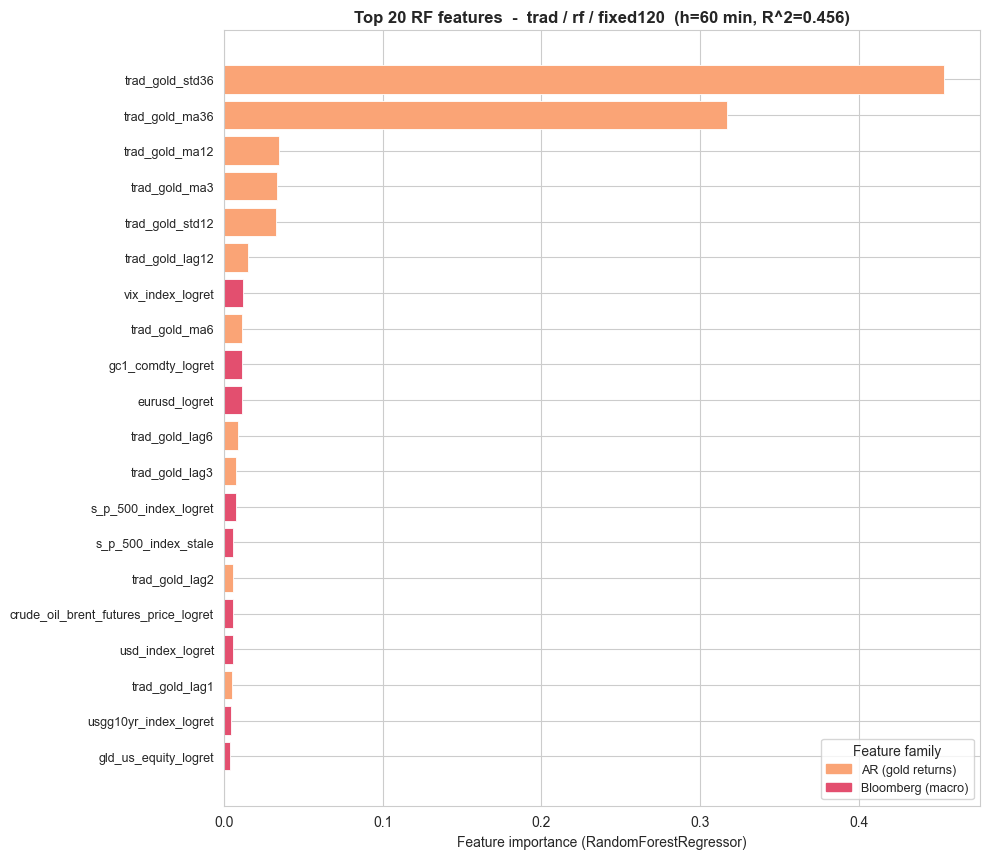

In [22]:
# %% -- GRAPH 13 : RF FEATURE IMPORTANCE (Matplotlib horizontal bar) --
G13_TOP_N = 20


def _classify_feature(name: str) -> str:
    """Crude feature-family classifier used only for colouring."""
    name_l = str(name).lower()
    if name_l.startswith('ar_') or name_l.startswith('trad_gold_'):
        return 'AR (gold returns)'
    if name_l in {'is_post_break', 'poly_movement_during_break',
                  'trad_movement_during_break'}:
        return 'Gap features'
    if (
        name_l.endswith('_logret') or name_l.endswith('_stale')
        or name_l.endswith('_diff')
        or any(k in name_l for k in ('crude_oil', 's_p_500', 'usd_index',
                                     'vix_index', 'usgg10yr', 'eurusd',
                                     'gc1_comdty', 'gld_us_equity'))
        or name_l.startswith('trad__')
    ):
        return 'Bloomberg (macro)'
    return 'Polymarket'


_family_colors = {
    'AR (gold returns)': PALETTE_HEX[1],
    'Bloomberg (macro)': PALETTE_HEX[3],
    'Polymarket':        PALETTE_HEX[-1],
    'Gap features':      PALETTE_HEX[0],
}

if ALL_SUMMARY.empty:
    print('No summary CSVs available -> skipping Graph 13.')
else:
    _rf_rows = ALL_SUMMARY[ALL_SUMMARY['model'].astype(str).str.lower() == 'rf'].dropna(subset=['r2'])
    if _rf_rows.empty:
        print('No Random-Forest rows in summaries -> skipping Graph 13.')
    else:
        _best_rf = _rf_rows.loc[_rf_rows['r2'].idxmax()]
        _rf_key = (
            'rf', str(_best_rf['window']), str(_best_rf['dataset']),
            int(_best_rf['horizon_min']),
        )
        _model_path = MODEL_FILES.get(_rf_key)
        if _model_path is None:
            print(
                f'  [warn] No RF .pkl found for best combo {_rf_key}; '
                f'skipping Graph 13.'
            )
        else:
            try:
                import joblib
                _rf_model = joblib.load(_model_path)
            except Exception as exc:
                print(f'  [warn] failed to load {_model_path.name}: {exc}')
                _rf_model = None
            if _rf_model is not None:
                _imp = np.asarray(getattr(_rf_model, 'feature_importances_', []))
                if _imp.size == 0:
                    print(
                        f'  [warn] {_model_path.name} has no feature_importances_; '
                        f'skipping Graph 13.'
                    )
                else:
                    _names = getattr(_rf_model, 'feature_names_in_', None)
                    if _names is None:
                        _names = np.array([f'feat_{i}' for i in range(len(_imp))])
                    _order = np.argsort(_imp)[::-1][:G13_TOP_N]
                    _top_imp = _imp[_order]
                    _top_names = [str(_names[i]) for i in _order]
                    _top_families = [_classify_feature(n) for n in _top_names]
                    _top_colors = [_family_colors.get(f, PALETTE_HEX[2]) for f in _top_families]

                    fig_g13, ax_g13 = plt.subplots(figsize=(10, 0.36 * len(_top_imp) + 1.5))
                    _y_pos = np.arange(len(_top_imp))[::-1]
                    ax_g13.barh(_y_pos, _top_imp, color=_top_colors,
                                edgecolor='white', linewidth=0.6)
                    ax_g13.set_yticks(_y_pos)
                    ax_g13.set_yticklabels(_top_names, fontsize=9)
                    ax_g13.set_xlabel('Feature importance (RandomForestRegressor)')
                    ax_g13.set_title(
                        f'Top {len(_top_imp)} RF features  -  '
                        f'{_rf_key[2]} / rf / {_rf_key[1]}  '
                        f'(h={_rf_key[3]} min, R^2={float(_best_rf["r2"]):.3f})',
                        fontweight='bold',
                    )
                    # Legend: one patch per family encountered.
                    import matplotlib.patches as mpatches
                    _fams_seen = []
                    for f in _top_families:
                        if f not in _fams_seen:
                            _fams_seen.append(f)
                    _handles = [
                        mpatches.Patch(color=_family_colors.get(f, PALETTE_HEX[2]), label=f)
                        for f in _fams_seen
                    ]
                    ax_g13.legend(handles=_handles, loc='lower right', fontsize=9,
                                  title='Feature family')
                    fig_g13.tight_layout()
                    plt.show()


## Table 1 - Best-window results summary (HTML for Google Docs / Overleaf paste)


In [23]:
# %% -- TABLE 1 : HTML SUMMARY (best window per (model, horizon)) -----
from IPython.display import HTML, display

# ----- Tunable knobs -------------------------------------------------
TABLE_DATASETS_FILTER = None          # None = one table per dataset; list to narrow
TABLE_EXPECTED_HORIZONS = [10, 15, 30, 45, 60]
TABLE_MODEL_ORDER = ['linear', 'rf', 'lstm', 'pls_ols', 'rf_pls', 'lstm_pls', 'lasso_cv']
TABLE_BEST_BY = 'rmse'                # 'rmse' (lowest) or 'r2' (highest)
TABLE_NUMERIC_FMT = '{:.4f}'          # printf-style format for the metric columns

MODEL_DISPLAY_NAMES = {
    'linear':   'Linear Regression',
    'rf':       'Random Forest',
    'lstm':     'LSTM',
    'pls_ols':  'PLS + OLS',
    'rf_pls':   'Random Forest + PLS',
    'lstm_pls': 'LSTM + PLS',
    'lasso_cv': 'Lasso CV',
}
WINDOW_DISPLAY_NAMES = {
    'fixed120':  'Fixed 120',
    'fixed240':  'Fixed 240',
    'fixed300':  'Fixed 300',
    'expanding': 'Expanding',
}
DATASET_DISPLAY_NAMES = {
    'ar_only':        'AR only',
    'bloomberg_only': 'Bloomberg only',
    'poly_only':      'Polymarket only',
    'trad':           'Bloomberg + AR (trad)',
    'poly':           'Polymarket + AR (poly)',
    'poly+trad':      'Polymarket + Bloomberg + AR (poly+trad)',
}


def _build_one_html_table(df_ds: pd.DataFrame, dataset_key: str) -> str:
    """Return an HTML string with rowspan on the Model column."""
    # Pre-build rows: one per (model, horizon) in the requested order.
    models_present = [m for m in TABLE_MODEL_ORDER if m in set(df_ds['model'])]
    # Append any extra models we did not anticipate (alphabetical).
    for extra in sorted(set(df_ds['model']) - set(TABLE_MODEL_ORDER)):
        models_present.append(extra)

    table_rows = []
    for model_key in models_present:
        for h in TABLE_EXPECTED_HORIZONS:
            sub = df_ds[(df_ds['model'] == model_key) & (df_ds['horizon_min'] == h)]
            display_model = MODEL_DISPLAY_NAMES.get(model_key, model_key)
            if sub.empty:
                table_rows.append({
                    'model_display': display_model,
                    'Horizon':       h,
                    'Best Window':   '',
                    'RMSE': '', 'MAE': '', 'R2': '', 'Dir_acc': '',
                })
                continue
            sub_valid = sub.dropna(subset=[TABLE_BEST_BY])
            if sub_valid.empty:
                table_rows.append({
                    'model_display': display_model,
                    'Horizon':       h,
                    'Best Window':   '',
                    'RMSE': '', 'MAE': '', 'R2': '', 'Dir_acc': '',
                })
                continue
            if TABLE_BEST_BY == 'rmse':
                best = sub_valid.loc[sub_valid['rmse'].idxmin()]
            elif TABLE_BEST_BY == 'r2':
                best = sub_valid.loc[sub_valid['r2'].idxmax()]
            else:
                raise ValueError(f"Unknown TABLE_BEST_BY={TABLE_BEST_BY!r}")
            table_rows.append({
                'model_display': display_model,
                'Horizon':       h,
                'Best Window':   WINDOW_DISPLAY_NAMES.get(best['window'], best['window']),
                'RMSE':          TABLE_NUMERIC_FMT.format(best['rmse']),
                'MAE':           TABLE_NUMERIC_FMT.format(best['mae']),
                'R2':            TABLE_NUMERIC_FMT.format(best['r2']),
                'Dir_acc':       TABLE_NUMERIC_FMT.format(best['dir_acc']),
            })

    # Inline styles - kept minimal so Google Docs paste preserves the structure.
    css_table  = ('border-collapse: collapse; border: 1px solid black; '
                  "font-family: Arial, sans-serif; font-size: 12px;")
    css_header = ('border: 1px solid black; padding: 6px 12px; '
                  'font-weight: bold; text-align: left; background-color: #ffffff;')
    css_cell   = 'border: 1px solid black; padding: 6px 12px; text-align: left;'

    out = [f'<table style="{css_table}">']
    out.append('  <thead><tr>')
    for col in ['Model', 'Horizon', 'Best Window', 'RMSE', 'MAE', 'R2', 'Dir_acc']:
        out.append(f'    <th style="{css_header}">{col}</th>')
    out.append('  </tr></thead>')
    out.append('  <tbody>')

    # Group consecutive rows by the same model -> emit rowspan once per group.
    i = 0
    while i < len(table_rows):
        model_label = table_rows[i]['model_display']
        # Find run length
        j = i
        while j < len(table_rows) and table_rows[j]['model_display'] == model_label:
            j += 1
        group = table_rows[i:j]
        for k, row in enumerate(group):
            out.append('    <tr>')
            if k == 0:
                out.append(
                    f'      <td style="{css_cell}" rowspan="{len(group)}">'
                    f'{model_label}</td>'
                )
            out.append(f'      <td style="{css_cell}">{row["Horizon"]}</td>')
            out.append(f'      <td style="{css_cell}">{row["Best Window"]}</td>')
            out.append(f'      <td style="{css_cell}">{row["RMSE"]}</td>')
            out.append(f'      <td style="{css_cell}">{row["MAE"]}</td>')
            out.append(f'      <td style="{css_cell}">{row["R2"]}</td>')
            out.append(f'      <td style="{css_cell}">{row["Dir_acc"]}</td>')
            out.append('    </tr>')
        i = j

    out.append('  </tbody>')
    out.append('</table>')
    return '\n'.join(out)


if 'ALL_SUMMARY' not in globals() or ALL_SUMMARY.empty:
    print('No summary CSVs loaded - run Stage 4 first; skipping Table 1.')
else:
    if TABLE_DATASETS_FILTER is None:
        _datasets_to_render = sorted(ALL_SUMMARY['dataset'].unique())
    else:
        _datasets_to_render = list(TABLE_DATASETS_FILTER)

    for _ds in _datasets_to_render:
        _df_ds = ALL_SUMMARY[ALL_SUMMARY['dataset'] == _ds]
        if _df_ds.empty:
            print(f"[skip] dataset '{_ds}' has no rows in ALL_SUMMARY")
            continue
        _ds_display = DATASET_DISPLAY_NAMES.get(_ds, _ds)
        _html_table = _build_one_html_table(_df_ds, _ds)

        # 1. Render visually so it can be visually inspected / pasted by selection.
        display(HTML(
            f'<h3 style="font-family: Arial, sans-serif;">'
            f'Dataset: {_ds_display}</h3>\n' + _html_table
        ))

        # 2. Print the raw HTML so the user can copy-paste verbatim.
        print(f'\n----- RAW HTML for dataset = {_ds!r} (copy block below) -----')
        print(_html_table)
        print('----- end raw HTML -----\n')



----- RAW HTML for dataset = 'ar_only' (copy block below) -----
<table style="border-collapse: collapse; border: 1px solid black; font-family: Arial, sans-serif; font-size: 12px;">
  <thead><tr>
    <th style="border: 1px solid black; padding: 6px 12px; font-weight: bold; text-align: left; background-color: #ffffff;">Model</th>
    <th style="border: 1px solid black; padding: 6px 12px; font-weight: bold; text-align: left; background-color: #ffffff;">Horizon</th>
    <th style="border: 1px solid black; padding: 6px 12px; font-weight: bold; text-align: left; background-color: #ffffff;">Best Window</th>
    <th style="border: 1px solid black; padding: 6px 12px; font-weight: bold; text-align: left; background-color: #ffffff;">RMSE</th>
    <th style="border: 1px solid black; padding: 6px 12px; font-weight: bold; text-align: left; background-color: #ffffff;">MAE</th>
    <th style="border: 1px solid black; padding: 6px 12px; font-weight: bold; text-align: left; background-color: #ffffff;">


----- RAW HTML for dataset = 'bloomberg_only' (copy block below) -----
<table style="border-collapse: collapse; border: 1px solid black; font-family: Arial, sans-serif; font-size: 12px;">
  <thead><tr>
    <th style="border: 1px solid black; padding: 6px 12px; font-weight: bold; text-align: left; background-color: #ffffff;">Model</th>
    <th style="border: 1px solid black; padding: 6px 12px; font-weight: bold; text-align: left; background-color: #ffffff;">Horizon</th>
    <th style="border: 1px solid black; padding: 6px 12px; font-weight: bold; text-align: left; background-color: #ffffff;">Best Window</th>
    <th style="border: 1px solid black; padding: 6px 12px; font-weight: bold; text-align: left; background-color: #ffffff;">RMSE</th>
    <th style="border: 1px solid black; padding: 6px 12px; font-weight: bold; text-align: left; background-color: #ffffff;">MAE</th>
    <th style="border: 1px solid black; padding: 6px 12px; font-weight: bold; text-align: left; background-color: #ff


----- RAW HTML for dataset = 'poly' (copy block below) -----
<table style="border-collapse: collapse; border: 1px solid black; font-family: Arial, sans-serif; font-size: 12px;">
  <thead><tr>
    <th style="border: 1px solid black; padding: 6px 12px; font-weight: bold; text-align: left; background-color: #ffffff;">Model</th>
    <th style="border: 1px solid black; padding: 6px 12px; font-weight: bold; text-align: left; background-color: #ffffff;">Horizon</th>
    <th style="border: 1px solid black; padding: 6px 12px; font-weight: bold; text-align: left; background-color: #ffffff;">Best Window</th>
    <th style="border: 1px solid black; padding: 6px 12px; font-weight: bold; text-align: left; background-color: #ffffff;">RMSE</th>
    <th style="border: 1px solid black; padding: 6px 12px; font-weight: bold; text-align: left; background-color: #ffffff;">MAE</th>
    <th style="border: 1px solid black; padding: 6px 12px; font-weight: bold; text-align: left; background-color: #ffffff;">R2<


----- RAW HTML for dataset = 'poly+trad' (copy block below) -----
<table style="border-collapse: collapse; border: 1px solid black; font-family: Arial, sans-serif; font-size: 12px;">
  <thead><tr>
    <th style="border: 1px solid black; padding: 6px 12px; font-weight: bold; text-align: left; background-color: #ffffff;">Model</th>
    <th style="border: 1px solid black; padding: 6px 12px; font-weight: bold; text-align: left; background-color: #ffffff;">Horizon</th>
    <th style="border: 1px solid black; padding: 6px 12px; font-weight: bold; text-align: left; background-color: #ffffff;">Best Window</th>
    <th style="border: 1px solid black; padding: 6px 12px; font-weight: bold; text-align: left; background-color: #ffffff;">RMSE</th>
    <th style="border: 1px solid black; padding: 6px 12px; font-weight: bold; text-align: left; background-color: #ffffff;">MAE</th>
    <th style="border: 1px solid black; padding: 6px 12px; font-weight: bold; text-align: left; background-color: #ffffff;


----- RAW HTML for dataset = 'poly_only' (copy block below) -----
<table style="border-collapse: collapse; border: 1px solid black; font-family: Arial, sans-serif; font-size: 12px;">
  <thead><tr>
    <th style="border: 1px solid black; padding: 6px 12px; font-weight: bold; text-align: left; background-color: #ffffff;">Model</th>
    <th style="border: 1px solid black; padding: 6px 12px; font-weight: bold; text-align: left; background-color: #ffffff;">Horizon</th>
    <th style="border: 1px solid black; padding: 6px 12px; font-weight: bold; text-align: left; background-color: #ffffff;">Best Window</th>
    <th style="border: 1px solid black; padding: 6px 12px; font-weight: bold; text-align: left; background-color: #ffffff;">RMSE</th>
    <th style="border: 1px solid black; padding: 6px 12px; font-weight: bold; text-align: left; background-color: #ffffff;">MAE</th>
    <th style="border: 1px solid black; padding: 6px 12px; font-weight: bold; text-align: left; background-color: #ffffff;


----- RAW HTML for dataset = 'trad' (copy block below) -----
<table style="border-collapse: collapse; border: 1px solid black; font-family: Arial, sans-serif; font-size: 12px;">
  <thead><tr>
    <th style="border: 1px solid black; padding: 6px 12px; font-weight: bold; text-align: left; background-color: #ffffff;">Model</th>
    <th style="border: 1px solid black; padding: 6px 12px; font-weight: bold; text-align: left; background-color: #ffffff;">Horizon</th>
    <th style="border: 1px solid black; padding: 6px 12px; font-weight: bold; text-align: left; background-color: #ffffff;">Best Window</th>
    <th style="border: 1px solid black; padding: 6px 12px; font-weight: bold; text-align: left; background-color: #ffffff;">RMSE</th>
    <th style="border: 1px solid black; padding: 6px 12px; font-weight: bold; text-align: left; background-color: #ffffff;">MAE</th>
    <th style="border: 1px solid black; padding: 6px 12px; font-weight: bold; text-align: left; background-color: #ffffff;">R2<